# 04 — Transferência de aprendizado (MobileNetV2)
**Classificação de gênero musical — GTZAN / CNN sobre espectrogramas Mel**

Segundo modelo do projeto: **transferência de aprendizado** com a **MobileNetV2**
pré-treinada na ImageNet, aplicada aos mesmos espectrogramas Mel de 3 s da baseline.

**Estratégia — extração de features.** Treinar a MobileNetV2 ponta a ponta em CPU seria
proibitivo (passar ~10 mil espectrogramas pela rede a cada época). Em vez disso, usamos o
backbone **congelado** para gerar um *embedding* de 1280 dimensões por segmento **uma única
vez** (cache) e treinamos apenas uma **cabeça densa** sobre esses vetores — rápido em CPU e
metodologicamente equivalente a *feature extraction*.

In [1]:
import sys, json
from pathlib import Path
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras

from src import config as C
from src import preprocess, models, evaluate

%matplotlib inline
plt.rcParams["figure.dpi"] = 100
models.set_seeds(C.SEED)

## 1. Embeddings da MobileNetV2

Os espectrogramas de 1 canal são repetidos para 3 canais e passam pela pré-processamento do
backbone. As features são geradas uma vez e salvas em `data/processed/emb_*` (padrão
*carregar-ou-computar*).

In [2]:
mel = preprocess.load_dataset("mel")

if preprocess.is_cached("emb"):
    print("Embeddings em cache — carregando.")
    emb = preprocess.load_dataset("emb")
else:
    print("Extraindo embeddings MobileNetV2 (alguns minutos em CPU)...")
    extractor = models.build_mobilenet_extractor()
    emb = {}
    for split in preprocess.SPLITS:
        X, y = mel[split]
        feats = extractor.predict(X.astype(np.float32), batch_size=64, verbose=0)
        emb[split] = (feats.astype(np.float32), y)
    preprocess.save_dataset(emb, "emb")

Etr, ytr = emb["train"]
Eva, yva = emb["val"]
Ete, yte = emb["test"]
print("Embeddings -> treino:", Etr.shape, "| val:", Eva.shape, "| teste:", Ete.shape)

Embeddings em cache — carregando.
Embeddings -> treino: (6985, 1280) | val: (1499, 1280) | teste: (1497, 1280)


## 2. Cabeça densa

Classificador raso sobre os embeddings: Dense(128) → Dropout(0,4) → softmax(10).

In [3]:
head = models.build_transfer_head(input_dim=Etr.shape[1])
head.summary()

Model: "transfer_head"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 165,258 (645.54 KB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Treinamento da cabeça

Como treina apenas sobre vetores de 1280 dimensões, é rápido — permitimos até 100 épocas
com *early stopping*. Modelo e histórico são salvos em `models/` (carregar-ou-treinar).

In [4]:
MODEL_PATH = C.MODELS_DIR / "transfer_head.keras"
HIST_PATH = C.MODELS_DIR / "transfer_history.json"

if MODEL_PATH.exists() and HIST_PATH.exists():
    print("Cabeça em cache — carregando.")
    head = keras.models.load_model(MODEL_PATH)
    history = json.loads(HIST_PATH.read_text())
else:
    h = head.fit(Etr, ytr, validation_data=(Eva, yva),
                 epochs=100, batch_size=128,
                 callbacks=models.default_callbacks(patience=10), verbose=2)
    history = h.history
    head.save(MODEL_PATH)
    evaluate.save_history(h, HIST_PATH)
print("Épocas registradas:", len(history["loss"]))

Cabeça em cache — carregando.
Épocas registradas: 51


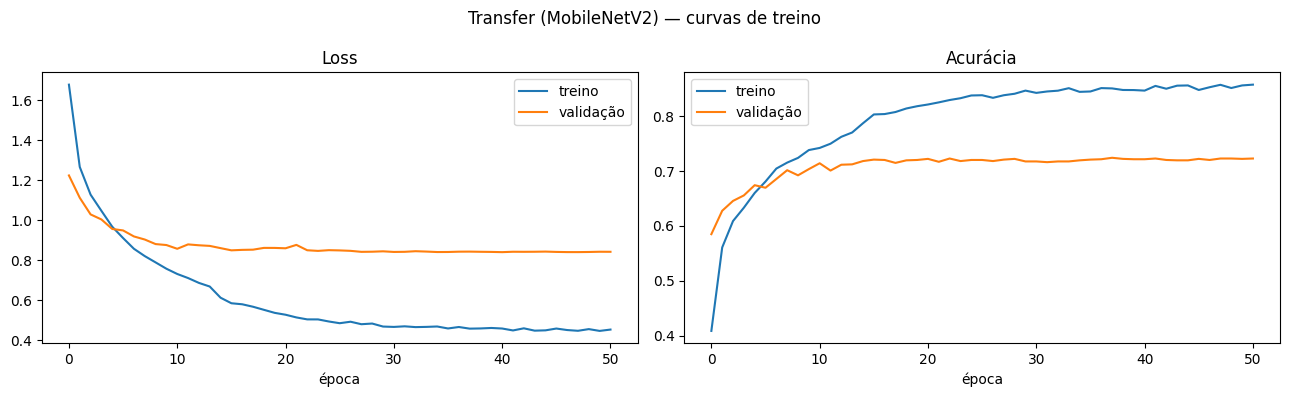

In [5]:
evaluate.plot_history(history, title="Transfer (MobileNetV2) — curvas de treino")
plt.show()

## 4. Avaliação no teste

In [6]:
res = evaluate.evaluate_model(head, Ete, yte)
print(f"Acurácia (teste): {res['accuracy']:.4f}")
print(f"F1 macro (teste): {res['f1_macro']:.4f}\n")
evaluate.print_report(yte, res["y_pred"])

Acurácia (teste): 0.7121
F1 macro (teste): 0.7065

              precision    recall  f1-score   support

       blues      0.693     0.873     0.773       150
   classical      0.850     0.953     0.899       149
     country      0.635     0.631     0.633       149
       disco      0.684     0.607     0.643       150
      hiphop      0.736     0.732     0.734       149
        jazz      0.789     0.747     0.767       150
       metal      0.823     0.900     0.860       150
         pop      0.679     0.707     0.693       150
      reggae      0.647     0.513     0.572       150
        rock      0.527     0.460     0.491       150

    accuracy                          0.712      1497
   macro avg      0.706     0.712     0.707      1497
weighted avg      0.706     0.712     0.706      1497



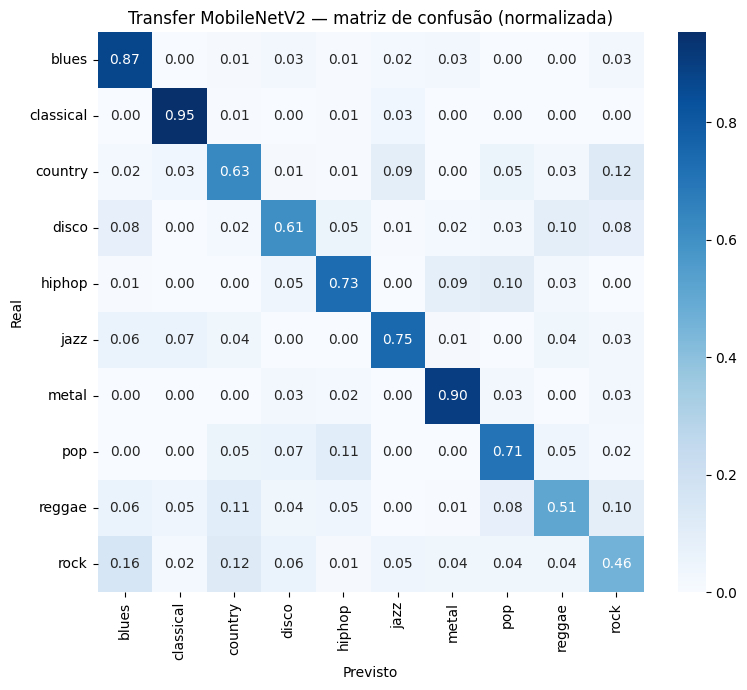

In [7]:
evaluate.plot_confusion_matrix(yte, res["y_pred"], normalize=True,
                               title="Transfer MobileNetV2 — matriz de confusão (normalizada)")
plt.show()

## 5. Resultados e comparação com a baseline

In [8]:
table = evaluate.append_result("transfer_mobilenetv2 (mel 3s)", res["accuracy"], res["f1_macro"])
print("Tabela de resultados acumulada:")
for k, v in table.items():
    print(f"  {k:35s}: acc={v['accuracy']:.4f}, f1={v['f1_macro']:.4f}")

Tabela de resultados acumulada:
  baseline_cnn (mel 3s)              : acc=0.5504, f1=0.5332
  transfer_mobilenetv2 (mel 3s)      : acc=0.7121, f1=0.7065


## 6. Síntese

Comparação direta com a CNN baseline (mesma entrada, mesmo split por música). Pontos a
discutir no relatório:

- A transferência de aprendizado supera (ou não) a baseline treinada do zero?
- A MobileNetV2 foi pré-treinada em fotos naturais (ImageNet); espectrogramas são um domínio
  distinto — daí *feature extraction* (sem fine-tuning) ser um ponto de partida razoável,
  mas com limitações.

**Próximo passo:** `05_evaluation_comparison.ipynb` — consolidar a comparação dos modelos e
da fonte de entrada (espectrograma librosa vs. PNG pronto).